In [42]:
import pandas as pd 
import xarray as xr
import numpy as np 
import matplotlib.pyplot as plt 
from  Divergencecals import *

## Sverdrup Calcuations based on ERA 5 winds for 3 degree box around palmyra 

- Curently am calculating this but do not know what the boundry conditions should be... 

In [101]:
wind = xr.open_dataset(r'Data\ERA5_10m_winds_monthly_Equatorial_basin_landmasked.nc')
wind = wind.sortby('latitude')
wind = wind.rename({'latitude': 'lat', 'longitude': 'lon'})
wind = wind.sel( lon = slice(125,280), lat = slice(0,10))
windm = wind.sel(valid_time = slice('2022-01-01', '2025-01-01'))
windm = windm.mean(dim='time')

In [78]:
def Calc_sverdrup(windm):
    from scipy.integrate import cumulative_trapezoid
    rho = 1.3 ## density of Air [kg/m^3]
    C_d = 1.25e-3  # wind stress coefient
    rho_w = 1025 # [kg/m^3]
    R = 6371e3 #radius 
    omega = 7.29e-5 # [1/s]

    dlat = np.deg2rad(np.gradient(windm.lat.values))
    dlon = np.deg2rad(np.gradient(windm.lon.values))
    # print(f"Lat: {len(dlat)} \nlon: {len(dlon )}")
    dy = R * dlat
    dx = R * dlon
    dlat_lon = np.cos(np.deg2rad(windm.lat.values)) ## how dlat varies with latitude 

    #Generate grid of dlat and dlon 
    dy_grid = np.repeat(dy.reshape(-1,1),len(dx), axis = 1)
    dx_grid = (np.repeat(dx.reshape(1,-1),len(dy), axis = 0).T *dlat_lon).T #transpose to match 
    # print(f'dy gird {dy_grid.shape}')
    # print(f'dy gird {dx_grid.shape}')

    U_w = np.sqrt(windm.uo**2 + windm.vo**2) ## Chat GPT says to Tau = rho * C_d * U * |U| ???? 
    windm['tau_u'] = rho*C_d*windm.uo*U_w # [N/m^2]
    windm['tau_v'] = rho*C_d*windm.vo*U_w # [N/m^2]

    windm['dy_tau_u']= windm.tau_u.differentiate(coord ='lat')/dy_grid/4 # [N/m^3]
    windm['dx_tau_v']= windm.tau_v.differentiate(coord ='lon')/dx_grid/4 # [N/m^3]
    windm['curl'] = windm.dx_tau_v - windm.dy_tau_u # [N/m^3]

    #windm['dy_curl'] = windm.curl.differentiate(coord = 'lat')/dy_grid # [N/m^4]

    lat = np.deg2rad(windm.lat) # [rad]

    B =  2*omega*np.cos(lat)/R # [1/m/s]

    V = windm['curl']/(rho_w*B)
    dV_dy = V.differentiate(coord = 'lat')/dy_grid/4
    dV_dy_filled = np.nan_to_num(dV_dy, nan=0.0)
    U = np.flip(cumulative_trapezoid(
        np.flip(dV_dy_filled, axis=1),
                dx = dx_grid[:,:-1], axis = 1),
                axis =1)
    U = np.where(np.isnan(dV_dy[:,:-1]), np.nan, U)
    U = xr.DataArray(U, dims = ['lat', 'lon'], coords = {'lat': windm.lat, 'lon' : windm.lon[:-1]})
    return U

U = Calc_sverdrup(windm)

In [79]:
U

<xarray.DataArray (lat: 41, lon: 620)> Size: 203kB
array([[51.47814727, 51.65682213, 51.92345046, ...,  9.86447469,
         4.67952466,         nan],
       [54.13545205, 54.28859185, 54.55552194, ...,  6.17698866,
         3.18765641,         nan],
       [27.7089904 , 27.61072802, 27.82742183, ...,  2.1482614 ,
         1.2768179 ,         nan],
       ...,
       [-7.89705862,         nan,         nan, ...,  0.09763062,
                nan,         nan],
       [-9.43936798,         nan,         nan, ...,  2.60607042,
         1.70590586,  0.59513943],
       [-9.27230524, -6.21217656,         nan, ...,  5.48464758,
         4.39600636,  2.1567978 ]], shape=(41, 620))
Coordinates:
  * lat      (lat) float64 328B 0.0 0.25 0.5 0.75 1.0 ... 9.0 9.25 9.5 9.75 10.0
  * lon      (lon) float64 5kB 125.0 125.2 125.5 125.8 ... 279.2 279.5 279.8

In [138]:
wind2022 = wind.sel(valid_time = slice('2022-01-01', '2023-01-01')).mean(dim = 'time')
wind2023 = wind.sel(valid_time = slice('2023-01-01', '2024-01-01')).mean(dim = 'time')
wind2024 = wind.sel(valid_time = slice('2024-01-01', '2025-01-01')).mean(dim = 'time')

U =     Calc_sverdrup(windm)
U2022 = Calc_sverdrup(wind2022)
U2023 = Calc_sverdrup(wind2023)
U2024 = Calc_sverdrup(wind2024)

U2022p = U2022.sel(lon = slice(-164+360, -160+360), lat = slice(2,10))
U2023p = U2023.sel(lon = slice(-164+360, -160+360), lat = slice(2,10))
U2024p = U2024.sel(lon = slice(-164+360, -160+360), lat = slice(2,10))

[Text(0, 0.5, 'Latitude'),
 Text(0.5, 0, 'zonal transport/unit width $\\frac{m^2}{s}$'),
 Text(0.5, 1.0, ' Sverdrup Zonal Transport \n Calcuated from ERA5,\n averaged over longitude near palmyra '),
 (-110.0, 125.0)]

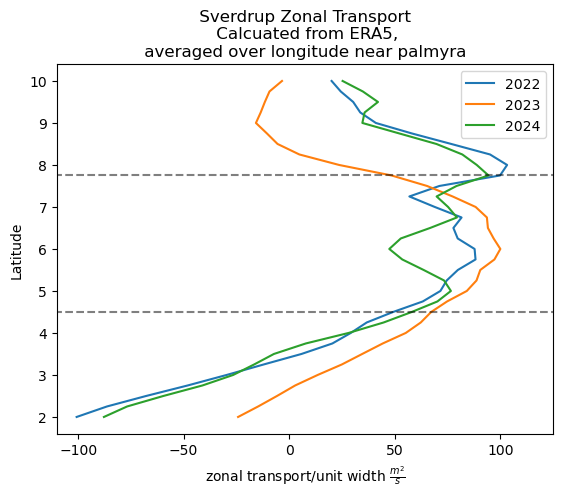

In [150]:
fig, ax = plt.subplots()
#ax.plot(U.mean(axis = 1), windm.lat, label = 'All years')
ax.plot(U2022p.mean(axis =1 ), U2022p.lat,label = 2022)
ax.plot(U2023p.mean(axis =1 ), U2023p.lat,label = 2023)
ax.plot(U2024p.mean(axis =1 ), U2024p.lat,label = 2024)
ax.legend()
ax.hlines(4.5,-200, 200 , alpha = 0.5, ls = "--", color = "k")
ax.hlines(7.75,-200, 200, alpha = 0.5, ls = "--", color = "k")
ax.set(ylabel = 'Latitude', xlabel = r'zonal transport/unit width $\frac{m^2}{s}$',
        title = ' Sverdrup Zonal Transport \n Calcuated from ERA5,\n averaged over longitude near palmyra '
       , xlim = [-110, 125])

[Text(0.5, 0, 'longitude'),
 Text(0, 0.5, 'latitude'),
 Text(0.5, 1.0, 'Zonal transport Sverdrup')]

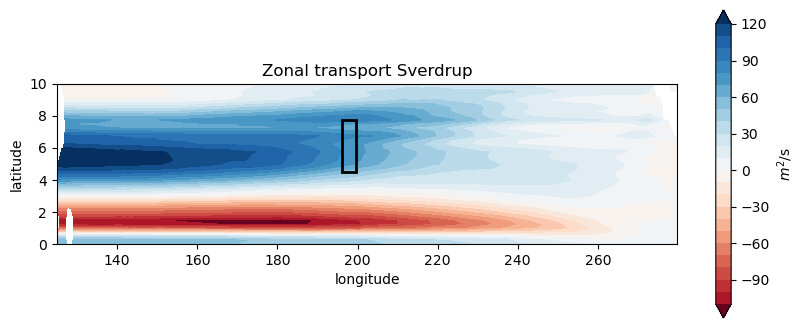

In [130]:
U = Calc_sverdrup(windm)
fig, ax = plt.subplots(figsize = (10,4))
x = windm.lon.values
y = windm.lat.values
X,Y = np.meshgrid(x,y)
vmax = np.nanmax(np.abs(U))
norm = plt.matplotlib.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

cbr = ax.contourf(
    X[:, :-1],
    Y[:, :-1],
    U,
    levels=25,
    cmap='RdBu',   # negative = red, positive = blue
    norm=norm,
    extend='both'
)
lon_left = (-163.75) % 360
lon_right = (-160.5) % 360
lat_top = 7.75
lat_bottom = 4.5

rect = plt.matplotlib.patches.Rectangle(
    (lon_left, lat_bottom),
    lon_right - lon_left,
    lat_top - lat_bottom,
    fill=False,
    edgecolor='k',
    linewidth=2
)
ax.add_patch(rect)
fig.colorbar(cbr, ax=ax, label = r'$m^2$/s')
ax.set_aspect(4)
ax.set(xlabel= 'longitude', ylabel = 'latitude', title = 'Zonal transport Sverdrup')

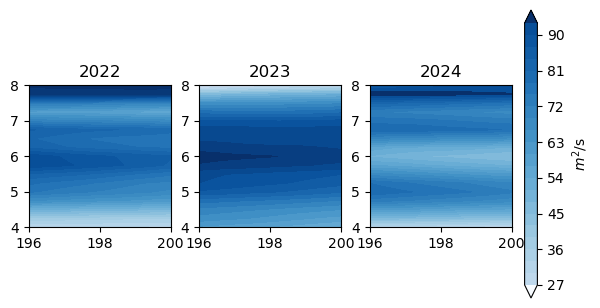

In [137]:
fig, axs = plt.subplots(1,3)
X, Y = np.meshgrid(U2022p.lon, U2022p.lat)
vmax = np.nanmax(np.stack([U2022p.values, U2023p.values, U2024p.values]))
norm = plt.matplotlib.colors.Normalize(vmin=0, vmax=vmax)
cmap = 'Blues'

axs[0].contourf(X, Y, U2022p, cmap=cmap, norm=norm, extend='max', levels=25)
axs[1].contourf(X, Y, U2023p, cmap=cmap, norm=norm, extend='max', levels=25)
cbr = axs[2].contourf(X,Y, U2024p, cmap=cmap, norm=norm, extend='both', levels = 25)
years = [2022,2023,2024]
for i, ax in enumerate(axs):
    ax.set_aspect('equal')
    ax.set_title(years[i])
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.2, 0.02, 0.6])
fig.colorbar(cbr, cax=cax, label=r'$m^2$/s')

In [ ]:
U

In [ ]:
def Calc_sverdrup(windm):
    from scipy.sparse.linalg import spsolve
    rho = 1.3 ## density of Air [kg/m^3]
    C_d = 1.25e-3  # wind stress coefient
    rho_w = 1025 # [kg/m^3]
    R = 6371e3 #radius of earth
    omega = 7.29e-5 # [1/s]
    
    latn, lonm = len(windm.lat.values), len(windm.lon.values)

    dx = 0.25
    dy = 0.25
    #Calcuate Tau 
    U_w = np.sqrt(windm.uo**2 + windm.vo**2) ## Chat GPT says to Tau = rho * C_d * U * |U| ???? 
    windm['tau_u'] = rho*C_d*windm.uo*U_w # [N/m^2]
    windm['tau_v'] = rho*C_d*windm.vo*U_w # [N/m^2]

    # take derivative of tau
    Dx,Dxx,Dy,Dyy = build_operators_dirichlet_top(latn,lonm,dx,dy)
    dy_tau_u = Dy@stack2d(windm['tau_u'].values) ## might need to multiply Dy to convert to meters
    dx_tau_v = Dx@stack2d(windm['tau_v'].values)

    curl = dx_tau_v - dy_tau_u
    curl_2d = unstack2d(curl, latn, lonm)
    lat = np.deg2rad(windm.lat.values) # [rad]

    B =  2*omega*np.cos(lat)/R # [1/m/s]
    print(B)
    B_grid = np.repeat(B.reshape(-1,1),lonm, axis = 1)
    psi = curl_2d/(rho_w*B_grid)
    dpsi_dy = Dy@stack2d(psi)

    LG2 = Dx
    psi = spsolve(LG2,dpsi_dy )
    U = unstack2d(psi,latn, lonm )
    return U

U = Calc_sverdrup(windm)

In [ ]:
def Calc_sverdrup2(ds):

    rho_air = 1.3
    Cd = 1.25e-3
    rho_w = 1025

    U = np.sqrt(ds.uo**2 + ds.vo**2)

    tau_x = rho_air * Cd * U * ds.uo
    tau_y = rho_air * Cd * U * ds.vo

    dx = 111e3 * np.cos(np.deg2rad(ds.lat))
    dy = 111e3

    d_tauy_dx = tau_y.differentiate('lon') / dx
    d_taux_dy = tau_x.differentiate('lat') / dy

    curl = d_tauy_dx - d_taux_dy

    omega = 7.29e-5
    R = 6371e3
    lat = np.deg2rad(ds.lat)

    beta = 2*omega*np.cos(lat)/R

    V = curl/(rho_w*beta)

    return V

In [ ]:
def Calc_sverdrup3(ds, return_zonal=True):
    """Compute meridional Sverdrup transport per unit width `V` and optionally
    the zonally-integrated meridional transport `U_zonal`.

    Returns:
      V: DataArray (lat, lon) meridional transport per unit width [m^2/s]
      U_zonal: DataArray (lat,) zonally-integrated meridional transport [m^2/s * m = m^3/s]
              (only returned if `return_zonal` is True).

    Clarification: The classical Sverdrup relation gives meridional transport per unit
    zonal width V = curl/(rho_w * beta) with units m^2/s. Integrating V across longitude
    (multiplying by dx [m] and summing) yields the total meridional transport across the
    basin at each latitude (units m^3/s). This function returns both so you can choose.
    """

    rho_air = 1.3
    Cd = 1.25e-3
    rho_w = 1025.0

    # wind speed magnitude
    Uwind = np.sqrt(ds.uo**2 + ds.vo**2)

    # wind stress components (N/m^2)
    tau_x = rho_air * Cd * Uwind * ds.uo
    tau_y = rho_air * Cd * Uwind * ds.vo

    # derivatives from xarray are in coordinate units (degrees). Convert to per-meter.
    # d(tau_y)/dx: differentiate wrt lon (deg) then divide by meters-per-degree-longitude
    d_tauy_dlon = tau_y.differentiate('lon')
    d_taux_dlat = tau_x.differentiate('lat')

    # meters per degree conversions
    meters_per_deg_lat = 111e3
    meters_per_deg_lon = 111e3 * np.cos(np.deg2rad(ds.lat))

    # convert per-degree derivatives to per-meter derivatives (xarray broadcasting)
    d_tauy_dx = d_tauy_dlon / meters_per_deg_lon
    d_taux_dy = d_taux_dlat / meters_per_deg_lat

    # curl (N/m^3)
    curl = d_tauy_dx - d_taux_dy

    # planetary beta (1/m/s)
    omega = 7.2921159e-5
    
    lat_rad = np.deg2rad(ds.lat)
    beta = 2 * omega * np.cos(lat_rad) / R
    beta_da = xr.DataArray(beta, coords={'lat': ds.lat}, dims=('lat',))

    # meridional transport per unit width V (m^2/s)
    V = curl / (rho_w * beta_da)

    if not return_zonal:
        return V

    # build dx (meters) per grid cell for zonal integration
    lon = ds.lon.values
    delta_lon = np.gradient(lon)  # degrees
    lat_vals = ds.lat.values
    lat_rad_vals = np.deg2rad(lat_vals)

    dx_per_lon = 111e3 * np.cos(lat_rad_vals)[:, None] * np.asarray(delta_lon)[None, :]
    dx_da = xr.DataArray(dx_per_lon, coords={'lat': ds.lat, 'lon': ds.lon}, dims=('lat', 'lon'))

    # zonally-integrated meridional transport (multiply V [m^2/s] by dx [m] -> m^3/s)
    U_zonal = (V * dx_da).sum(dim='lon')

    return V, U_zonal

In [ ]:
def Calc_sverdrup4(windm):
    rho_air = 1.3
    rho_w = 1025
    C_d = 1.25e-3
    omega = 7.29e-5
    R = 6371e3

    lat = np.deg2rad(windm.lat)

    # Grid spacing
    dlat = np.deg2rad(np.gradient(windm.lat.values))
    dlon = np.deg2rad(np.gradient(windm.lon.values))

    dy = R * dlat
    dx = R * dlon 
    dlat_lon = np.cos(np.deg2rad(windm.lat.values))
    dy_grid = np.repeat(dy.reshape(-1,1),len(dx), axis = 1)

    dx_grid = (np.repeat(dx.reshape(1,-1),len(dy), axis = 0).T *dlat_lon).T 

    # Wind stress
    U_mag = np.sqrt(windm.uo**2 + windm.vo**2)

    tau_x = rho_air * C_d * windm.uo**2
    tau_y = rho_air * C_d * windm.vo**2

    # Curl
    d_tauy_dx = tau_y.differentiate('lon') / dx_grid
    d_taux_dy = tau_x.differentiate('lat') / dy_grid

    curl = d_tauy_dx - d_taux_dy

    # Beta
    beta = 2 * omega * np.cos(lat) / R

    # Sverdrup transport (integrate from east)
    U = -(1 / (rho_w * beta)) * curl.cumsum(dim='lon') #* dx_grid

    return U
U = Calc_sverdrup(windm)